In [18]:
# ===============================
# import packages
# ===============================
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from datetime import datetime as dt, timezone, timedelta
from pathlib import Path
from zoneinfo import ZoneInfo
import squarify
from highlight_text import ax_text
import traceback
from instagrapi import Client
from dotenv import load_dotenv
import os

In [20]:
# ===============================
# system paths
# ===============================
script_dir = Path.cwd().parent
output_dir = script_dir / "data"

output_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
# ===============================
# Elexon generation data
# ===============================
# API request - generation data
url = 'https://data.elexon.co.uk/bmrs/api/v1/generation/outturn/summary'

LONDON = ZoneInfo("Europe/London")

now_uk = dt.now(LONDON)
most_recent_monday = now_uk.date() - timedelta(days=now_uk.weekday())
week_start = most_recent_monday - timedelta(days=7)
week_end = most_recent_monday - timedelta(days=1)

start_dt = dt(week_start.year, week_start.month, week_start.day, tzinfo=LONDON)
end_dt = dt(most_recent_monday.year, most_recent_monday.month, most_recent_monday.day, tzinfo=LONDON)

start_date = start_dt.astimezone(timezone.utc).strftime('%Y-%m-%d %H:%M:%S')
end_date = end_dt.astimezone(timezone.utc).strftime('%Y-%m-%d %H:%M:%S')

params = {
    'startTime' : start_date,
    'endTime' : end_date
}

response = requests.get(url, params = params)

if response.status_code == 200:
    print('Elexon generation API call successful!')
else:
    raise Exception(f"Elexon API failed. Status code: {response.status_code}")

gen = response.json()

# convert json return to df
gen = pd.json_normalize(
    gen,
    record_path=['data'],
    meta=['startTime', 'settlementPeriod']
)

gen['settlementPeriod'] = pd.to_numeric(gen['settlementPeriod'])

gen['startTime'] = pd.to_datetime(gen['startTime'], utc=True).dt.tz_convert(LONDON)

gen = gen[(gen['startTime'].dt.date >= week_start) & (gen['startTime'].dt.date <= week_end)]

# make sure Elexon has actually published the full week before we plot it
expected_periods = 48 * 7
actual_periods = gen[['startTime', 'settlementPeriod']].drop_duplicates().shape[0]

if actual_periods < expected_periods:
    missing = expected_periods - actual_periods
    raise Exception(
        f"Incomplete Elexon data for {week_start} to {week_end}: "
        f"expected {expected_periods} settlement periods, got {actual_periods} "
        f"({missing} missing) - Elexon likely hasn't published the rest yet."
    )

gen['startTime'] = gen['startTime'].dt.strftime('%Y-%m-%d')

# pivot wide
gen = gen.pivot_table(
    index=['startTime', 'settlementPeriod'],
    columns='fuelType',
    values='generation'
).reset_index().rename_axis(None, axis=1)


2026-08-09 23:00:00
2026-08-16 23:00:00
Elexon generation API call successful!


In [22]:
# ===============================
# NESO demand data
# ===============================
# API request - NESO demand data
dmnd = pd.read_csv('https://api.neso.energy/dataset/7a12172a-939c-404c-b581-a6128b74f588/resource/177f6fa4-ae49-4182-81ea-0c6b35f26ca6/download/demanddataupdate.csv')

dmnd = pd.DataFrame(dmnd)

dmnd = dmnd.rename(
    columns={
        'SETTLEMENT_DATE': 'startTime',
        'SETTLEMENT_PERIOD': 'settlementPeriod'
    }
)

In [23]:
# ===============================
# merge data to one df
# ===============================
merged_data = pd.merge(dmnd, gen, on=['startTime', 'settlementPeriod'])

grid = merged_data[[
    'startTime',
    'settlementPeriod',
    'OIL',
    'CCGT',
    'OCGT',
    'COAL',
    'BIOMASS',
    'NUCLEAR',
    'WIND',
    'EMBEDDED_WIND_GENERATION',
    'EMBEDDED_SOLAR_GENERATION',
    'NPSHYD',
    'PS',
    'OTHER',
    'INTELEC',
    'INTFR',
    'INTIFA2',
    'INTNED',
    'INTIRL',
    'INTEW',
    'INTNEM',
    'INTNSL',
    'INTVKL'
]]

grid['startTime'] = pd.to_datetime(grid['startTime'])
grid['timestamp'] = grid['startTime'] + pd.to_timedelta((grid['settlementPeriod'] -1) * 30, unit='m')

grid = grid.drop('startTime', axis='columns')

grid = (
    grid
    .rename(columns={
        'OIL': 'oil',
        'CCGT': 'ccgt',
        'OCGT': 'ocgt',
        'COAL': 'coal',
        'BIOMASS': 'biomass',
        'NUCLEAR': 'nuclear',
        'WIND': 'wind',
        'EMBEDDED_WIND_GENERATION': 'wind_embedded',
        'EMBEDDED_SOLAR_GENERATION': 'solar',
        'PS': 'pumped_storage_hydro',
        'NPSHYD': 'non_pumped_storage_hydro',
        'OTHER': 'other'
    })
    .assign(
        gas = lambda x: x['ocgt'] + x['ccgt'],
        wind = lambda x: x['wind'] + x['wind_embedded'],
        hydro = lambda x: x['pumped_storage_hydro'] + x['non_pumped_storage_hydro']
    )
)

grid = grid.drop(columns=['ocgt', 'ccgt', 'wind_embedded', 'pumped_storage_hydro', 'non_pumped_storage_hydro', 'other'])

start_cols = ['timestamp', 'settlementPeriod', 'gas']
ordered_cols = start_cols + [c for c in grid.columns if c not in start_cols]
grid = grid[ordered_cols]
grid = grid.fillna(0)

energy_categories = { 
    'gas': 'Fossil', 
    'oil': 'Fossil', 
    'coal': 'Fossil', 
    'biomass': 'Other',
    'nuclear': 'Other', 
    'wind': 'Renewable',
    'solar': 'Renewable', 
    'hydro': 'Renewable',
    'other': 'Other', 
    'INTELEC': 'Interconnector', 
    'INTFR': 'Interconnector', 
    'INTIFA2': 'Interconnector',
    'INTNED': 'Interconnector', 
    'INTIRL': 'Interconnector', 
    'INTEW': 'Interconnector', 
    'INTGRNL': 'Interconnector', 
    'INTNEM': 'Interconnector', 
    'INTNSL': 'Interconnector', 
    'INTVKL': 'Interconnector'
}

grid_long = grid.melt(id_vars=['timestamp', 'settlementPeriod'],
                      var_name='source',
                      value_name='mw')

grid_long['category'] = grid_long['source'].map(energy_categories)

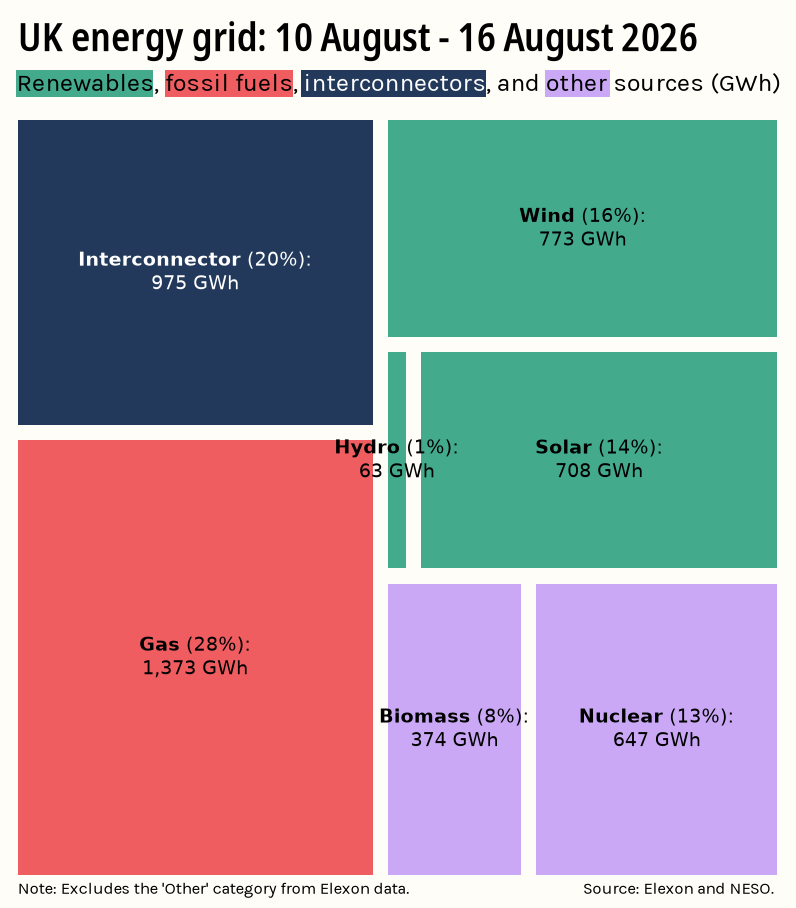

In [28]:
# ===============================
# treemap visualization - energy by source
# ===============================
treemap_data = (
    grid_long
    .assign(mwh=grid_long['mw'] * 0.5)
    .groupby(['category', 'source'], as_index=False)['mwh'].sum()
)


treemap_data = treemap_data[treemap_data['mwh'] > 0].dropna(subset='mwh')

interconnectors = ['INTELEC', 'INTFR', 'INTIFA2', 'INTNED', 'INTIRL', 'INTEW', 'INTGRNL', 'INTNEM', 'INTNSL', 'INTVKL']

treemap_data = treemap_data.assign(type = np.where(
    treemap_data['source'].isin(interconnectors),
    'interconnector',
    treemap_data['source']
))

treemap_data = treemap_data.groupby(['category', 'type'], as_index=False)['mwh'].sum()
treemap_data['proportion'] = ((treemap_data['mwh'] / treemap_data['mwh'].sum()) * 100).round().astype(int)


# treemap labels
labels = [
    f"$\\bf{{{type.title()}}}$ ({proportion}%):\n{(mwh / 1000):,.0f} GWh"
    for type, mwh, proportion in zip(treemap_data['type'], treemap_data['mwh'], treemap_data['proportion'])
]

# treemap font settings
title_font = {'fontname':'Noto Sans Condensed SemiBold', 'fontsize': 28}
date_font = {'fontname':'Noto Sans Condensed SemiBold', 'fontsize': 26}
subtitle_font = {'fontname':'Karla', 'fontsize': 18}
source_font = {'fontname':'Karla', 'fontsize': 12, 'c': '#818589'}

# define text strings

week_start = grid_long['timestamp'].min()
week_end = (grid_long['timestamp'].min() + timedelta(days=6))

main_text = f"UK energy grid: {week_start.strftime('%d %B')} - {week_end.strftime('%d %B %Y')}"
sub_text = "<Renewables>, <fossil fuels>, <interconnectors>, and <other> sources (GWh)"
source_text = "Source: Elexon and NESO."
note_text = "Note: Excludes the 'Other' category from Elexon data."


# treemap colours
colour_map = {
    'Fossil' : '#EF5D60', 
    'Interconnector': '#23395B', 
    'Other': '#CAA8F5', 
    'Renewable': '#43AA8B'
}

# subtitle highlight colours
colors = treemap_data['category'].map(colour_map)

subtitle_colours = colors.unique().tolist()


# create plot
fig, ax = plt.subplots(figsize=(10,10), facecolor="#FFFDF7")
ax.set_axis_off()

squarify.plot(sizes=treemap_data['mwh'], 
              label=labels, 
              color = colors, 
              pad=True,
              text_kwargs={
        "fontsize": 14,
        "color": "black",
        "horizontalalignment": "center", 
        "verticalalignment": "center",
    })

# add supporting text
ax.text(0.01, 1.065, main_text, transform=ax.transAxes, ha='left', va='bottom', **title_font)

# uses the highlight-text library for changing colours to suit highlights 
ax_text(0.8, 102, sub_text, transform=ax.transAxes, ha='left', va='bottom',  
        highlight_textprops=[
            {"color": 'black'},
            {"color": 'black'},
            {"color": 'w'},
            {"color": 'black'}
        ],
        **subtitle_font)
ax.text(0.74, -0.02, source_text, transform=ax.transAxes, ha='left', va='bottom', **source_font)
ax.text(0.01, -0.02, note_text, transform=ax.transAxes, ha='left', va='bottom', **source_font)


# subtitle colour highlights
rect1 = patches.Rectangle((0.8, 102), 17.7, 3.5, linewidth=1, facecolor=subtitle_colours[3], zorder=1, clip_on=False)
rect2 = patches.Rectangle((20, 102), 16.5, 3.5, linewidth=1, facecolor=subtitle_colours[0], zorder=1, clip_on=False)
rect3 = patches.Rectangle((37.5, 102), 23.9, 3.5, linewidth=1, facecolor=subtitle_colours[1], zorder=1, clip_on=False)
rect4 = patches.Rectangle((69, 102), 8.4, 3.5, linewidth=1, facecolor=subtitle_colours[2], zorder=1, clip_on=False)

ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)
ax.add_patch(rect4)

shortlist = ['interconnector']

# treemap labels
white_labels = [
    f"$\\bf{{{type.title()}}}$ ({proportion}%):\n{(mwh / 1000):,.0f} GWh"
    for type, mwh, proportion in zip(treemap_data['type'], treemap_data['mwh'], treemap_data['proportion']) if type in shortlist
]

for text in ax.texts:
    if text.get_text() in white_labels:
        text.set_color('white')
    else:
        text.set_color('black')

# save final image
image_output_dir = script_dir / "images"

image_output_dir.mkdir(parents=True, exist_ok=True)



plt.savefig(image_output_dir / f"{week_start.strftime('%d-%m-%Y')}_{week_end.strftime('%d-%m-%Y')}.png", dpi=300, bbox_inches="tight")

# show plot
plt.show()


In [ ]:
# ===============================
# automate posting to Instagram
# ===============================
# load_dotenv()

# user = os.getenv("INSTA_USERNAME") 
# password = os.getenv("PASSWORD")

# try:
#     cl = Client()
#     cl.login(username=user, password=password)

#     image_folder = image_output_dir
#     images = os.listdir(image_folder)

#     def post_image(image_path, caption):
#         try:
#             cl.photo_upload(path=image_path, caption=caption)
#         except Exception as e:
#             print(f"Error uploading Instagram post: {e}")
#             traceback.print_exc()

#     if images:
#         final_image = images[0]
#         caption = "A test caption for the post"
#         post_image(os.path.join(image_folder, final_image), caption)

# except Exception as e:
#     print(f"An error occurred: {e}")
#     traceback.print_exc()
# finally:
#     cl.logout()